<a href="https://colab.research.google.com/github/correajoao440-dotcom/fonte-de-informa-o-e-banco-de-dados-/blob/main/consumodecervejaemSP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dongeorge/beer-consumption-sao-paulo")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'beer-consumption-sao-paulo' dataset.
Path to dataset files: /kaggle/input/beer-consumption-sao-paulo


In [3]:
import pandas as pd
import os

# List files in the downloaded path
files_in_path = os.listdir(path)
print(f"Files in the dataset directory: {files_in_path}")

# Assuming the main data file is a CSV and taking the first one found
csv_files = [f for f in files_in_path if f.endswith('.csv')]
if csv_files:
    data_file = os.path.join(path, csv_files[0])
    df = pd.read_csv(data_file)
    print("Dataset loaded successfully into a Pandas DataFrame.")
    print("First 5 rows of the DataFrame:")
    print(df.head(10))
else:
    print("No CSV files found in the dataset directory.")


Files in the dataset directory: ['Consumo_cerveja.csv']
Dataset loaded successfully into a Pandas DataFrame.
First 5 rows of the DataFrame:
         Data Temperatura Media (C) Temperatura Minima (C)  \
0  2015-01-01                  27,3                   23,9   
1  2015-01-02                 27,02                   24,5   
2  2015-01-03                 24,82                   22,4   
3  2015-01-04                 23,98                   21,5   
4  2015-01-05                 23,82                     21   
5  2015-01-06                 23,78                   20,1   
6  2015-01-07                    24                   19,5   
7  2015-01-08                  24,9                   19,5   
8  2015-01-09                  28,2                   21,9   
9  2015-01-10                 26,76                   22,1   

  Temperatura Maxima (C) Precipitacao (mm)  Final de Semana  \
0                   32,5                 0              0.0   
1                   33,5                 0         

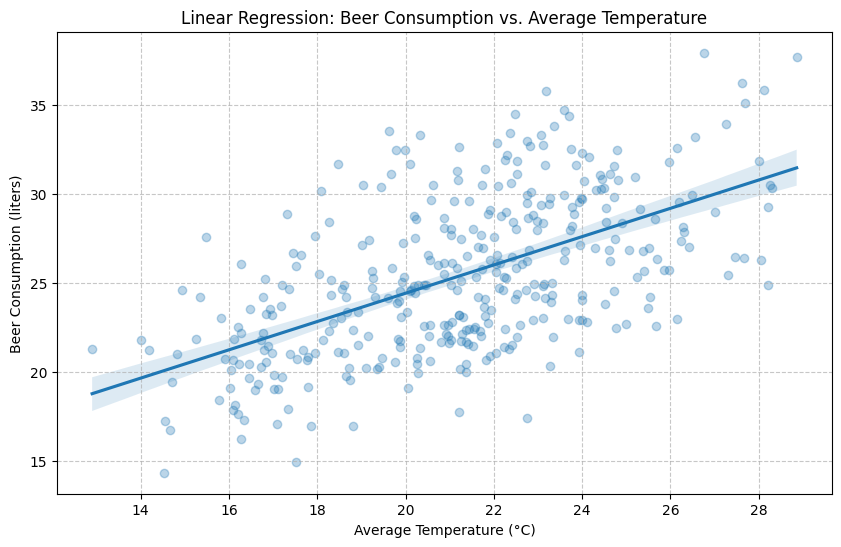

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Clean column names by removing extra spaces if any
df.columns = df.columns.str.strip()

# List of columns that use comma as decimal separator and need conversion
comma_decimal_columns = [
    'Temperatura Media (C)',
    'Temperatura Minima (C)',
    'Temperatura Maxima (C)',
    'Precipitacao (mm)'
]

for col in comma_decimal_columns:
    # Only attempt conversion if the column is of object type (likely string)
    if df[col].dtype == 'object':
        df[col] = df[col].str.replace(',', '.', regex=False)
    # Convert to numeric, coercing errors to NaN
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Ensure 'Consumo de cerveja (litros)' is numeric. It seems to already use '.' as a decimal.
df['Consumo de cerveja (litros)'] = pd.to_numeric(df['Consumo de cerveja (litros)'], errors='coerce')

# Drop rows with NaN values in the relevant columns for plotting
df_cleaned = df.dropna(subset=['Temperatura Media (C)', 'Consumo de cerveja (litros)']).copy()

# Create the linear regression plot
plt.figure(figsize=(10, 6))
sns.regplot(x='Temperatura Media (C)', y='Consumo de cerveja (litros)', data=df_cleaned, scatter_kws={'alpha':0.3})
plt.title('Linear Regression: Beer Consumption vs. Average Temperature')
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Beer Consumption (liters)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()
